## ARVORE DE DECISÃO

## Obtendo dados 

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
import pandas as pd

caminho = '../dataset/IA_Impacta_JOBs.csv'

df = pd.read_csv(caminho, sep=';')

df.head()

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-1064
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,1905
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,1705
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-247
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,703


In [21]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Employee_ID            2000 non-null   str  
 1   Age                    2000 non-null   int64
 2   Gender                 2000 non-null   str  
 3   Education_Level        2000 non-null   str  
 4   Industry               2000 non-null   str  
 5   Job_Role               2000 non-null   str  
 6   Years_Experience       2000 non-null   int64
 7   AI_Adoption_Level      2000 non-null   str  
 8   Automation_Risk        2000 non-null   str  
 9   Upskilling_Required    2000 non-null   str  
 10  Salary_Before_AI       2000 non-null   int64
 11  Salary_After_AI        2000 non-null   int64
 12  Job_Status             2000 non-null   str  
 13  Work_Hours_Per_Week    2000 non-null   int64
 14  Remote_Work            2000 non-null   str  
 15  Job_Satisfaction       2000 non-null   int64
 16 

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,40.5580,10.786418,22.0,32.00,40.0,50.00,59.0
Years_Experience,2000.0,16.6635,10.746675,0.0,8.00,16.0,26.00,37.0
Salary_Before_AI,2000.0,73942.0725,26055.823793,30036.0,51665.50,74620.0,95418.25,119976.0
Salary_After_AI,2000.0,78428.6425,29351.599013,24447.0,54086.75,76820.5,100730.25,161745.0
Work_Hours_Per_Week,2000.0,44.8510,5.712540,35.0,40.00,45.0,50.00,54.0
Job_Satisfaction,2000.0,6.0205,2.006263,3.0,4.00,6.0,8.00,9.0
Productivity_Change_%,2000.0,875.2080,1650.411046,-1999.0,-368.75,604.0,2241.25,3999.0


## EDA

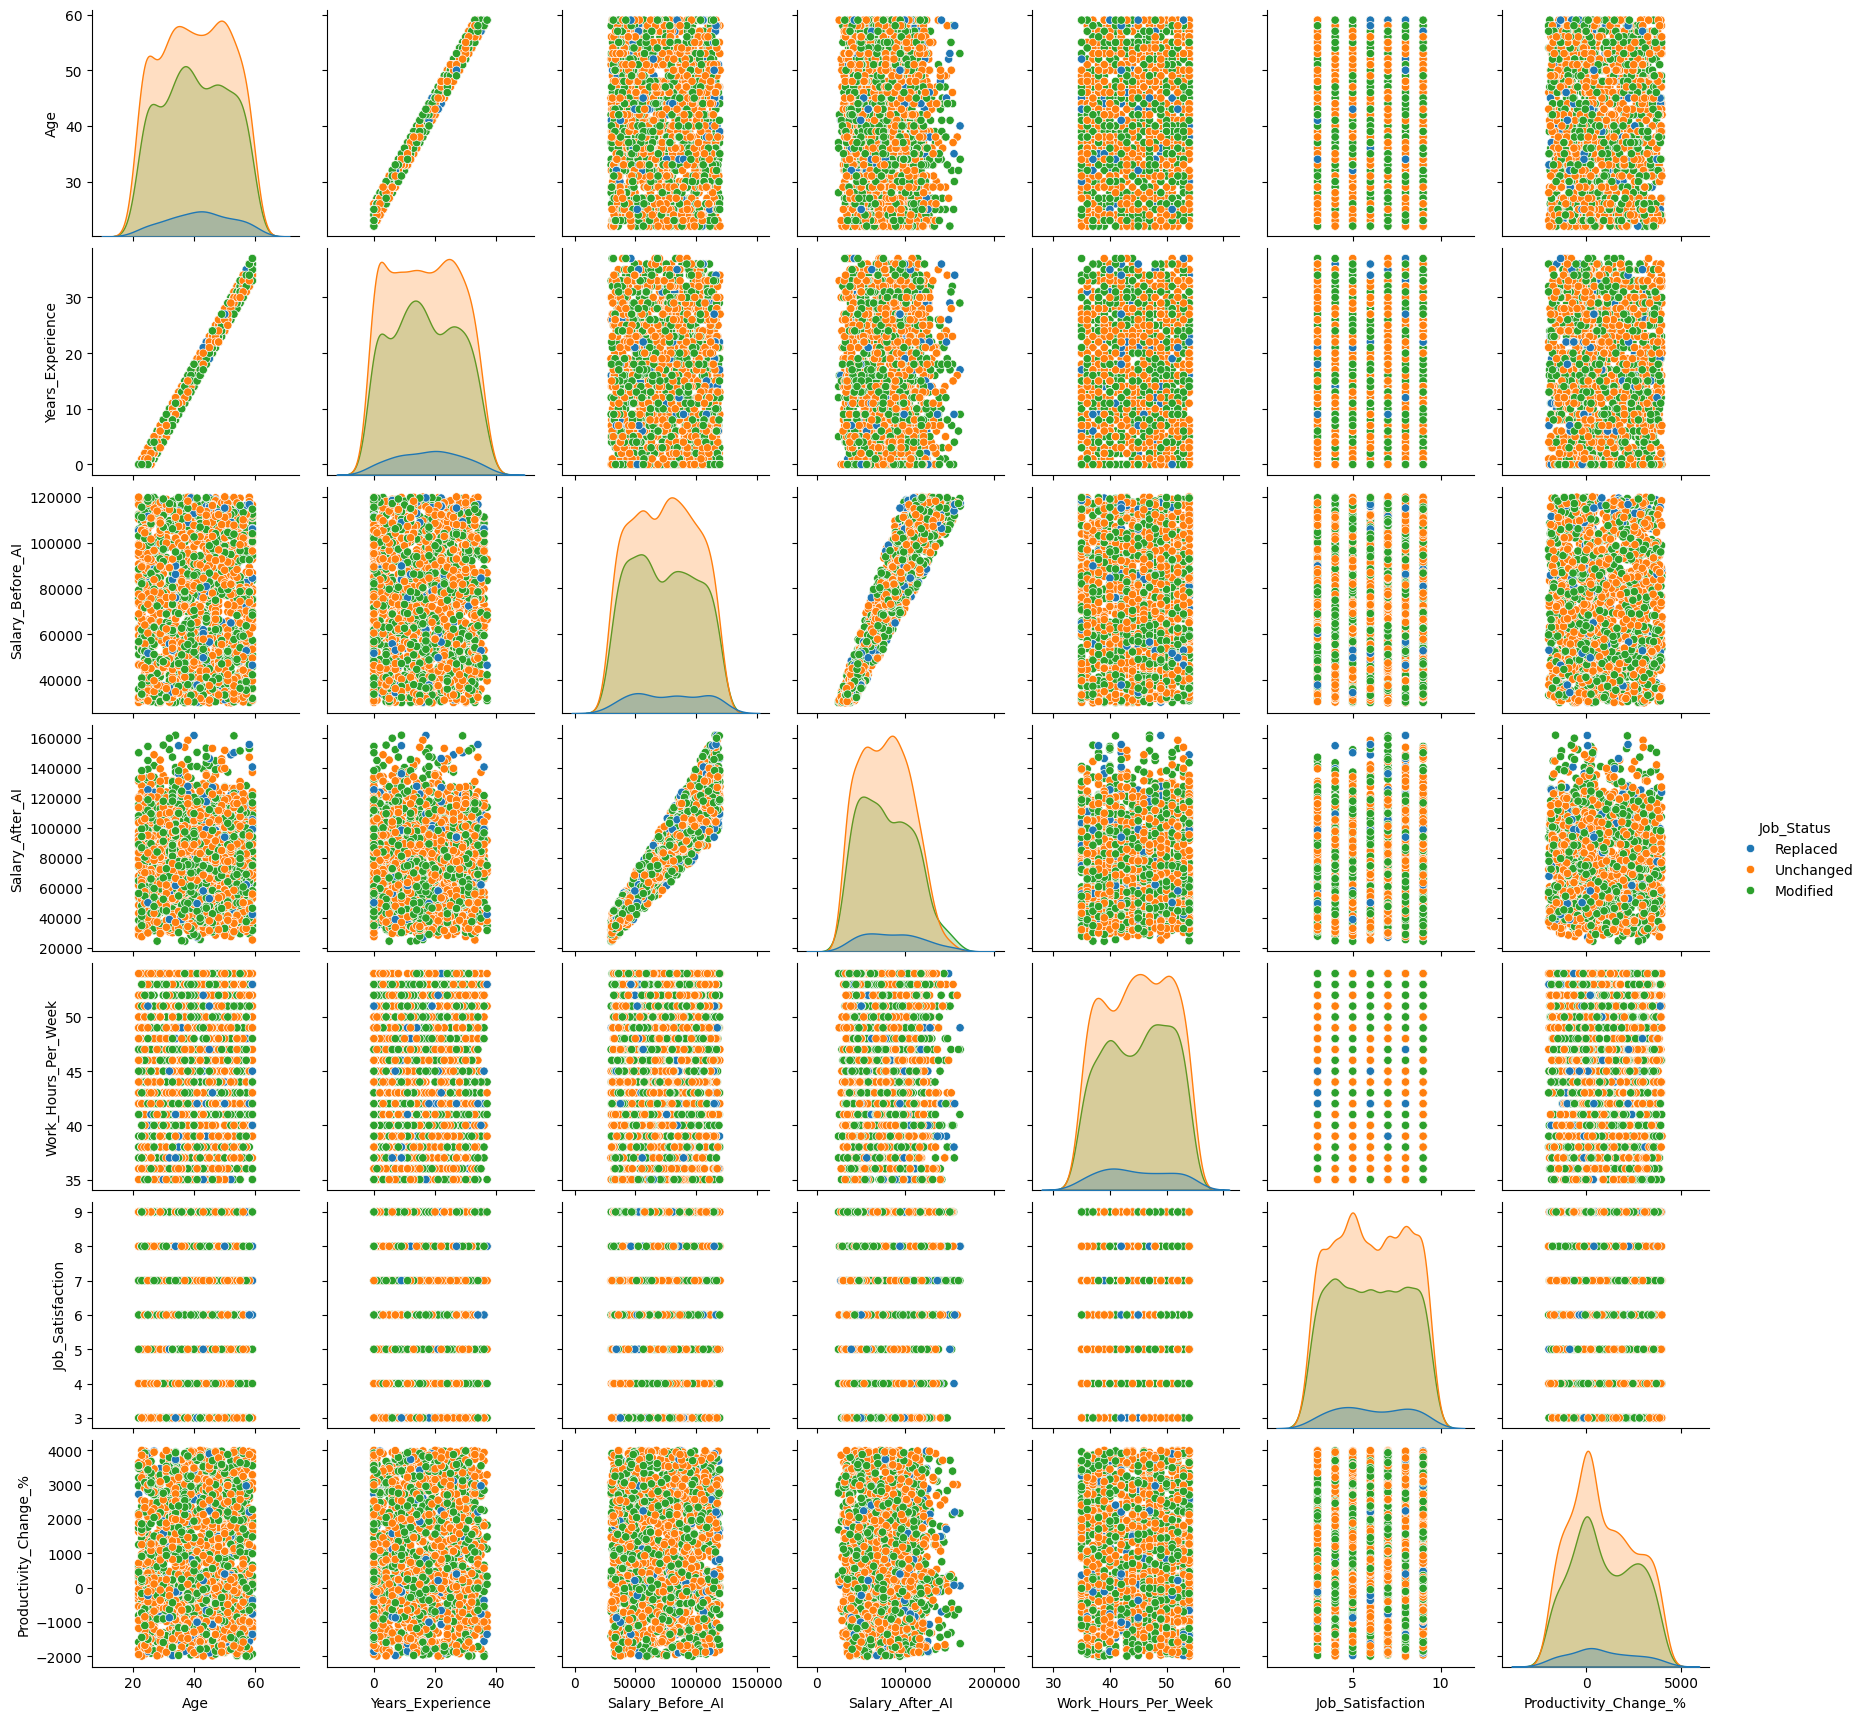

In [23]:
sns.pairplot(df, hue='Job_Status', diag_kind='kde')

In [24]:
df.drop (columns=['Employee_ID', 'Salary_After_AI', 'Productivity_Change_%'], inplace=True)
df.head()

,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction
0,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,Replaced,45,No,5
1,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,Unchanged,36,Yes,6
2,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,Modified,46,Yes,3
3,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,Modified,50,No,9
4,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,Modified,52,Yes,6


## Preparação dos dados para treinamento

In [25]:
from sklearn.model_selection import train_test_split

# Separar features (X) e target (y)
X = df.drop('Job_Status', axis=1)
y = df['Job_Status']

# Dividir os dados em treino e teste (75% treino, 25% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Tamanho do conjunto de treino: {X_train.shape}")
print(f"Tamanho do conjunto de teste: {X_test.shape}")
print(f"\nDistribuição do target no treino:\n{y_train.value_counts()}")
print(f"\nDistribuição do target no teste:\n{y_test.value_counts()}")

Tamanho do conjunto de treino: (1500, 13)
Tamanho do conjunto de teste: (500, 13)

Distribuição do target no treino:
Job_Status
Unchanged    822
Modified     602
Replaced      76
Name: count, dtype: int64

Distribuição do target no teste:
Job_Status
Unchanged    271
Modified     199
Replaced      30
Name: count, dtype: int64


In [26]:
from sklearn.preprocessing import LabelEncoder

# Identificar colunas categóricas
colunas_categoricas = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"Colunas categóricas encontradas: {colunas_categoricas}")

# Criar dicionário de encoders
encoders = {}

# Aplicar LabelEncoder em cada coluna categórica
for coluna in colunas_categoricas:
    encoders[coluna] = LabelEncoder()
    X_train[coluna] = encoders[coluna].fit_transform(X_train[coluna])
    X_test[coluna] = encoders[coluna].transform(X_test[coluna])

# Codificar o target (y) também
encoder_target = LabelEncoder()
y_train = encoder_target.fit_transform(y_train)
y_test_encoded = encoder_target.transform(y_test)

print("\nDados preparados e codificados com sucesso!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Colunas categóricas encontradas: ['Gender', 'Education_Level', 'Industry', 'Job_Role', 'AI_Adoption_Level', 'Automation_Risk', 'Upskilling_Required', 'Remote_Work']

Dados preparados e codificados com sucesso!
X_train shape: (1500, 13)
X_test shape: (500, 13)


C:\Users\jean\AppData\Local\Temp\ipykernel_19768\1442299921.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = X_train.select_dtypes(include=['object']).columns.tolist()


## CRIANDO MODELO DE ARVORE DE DECISAO

In [27]:
from sklearn.tree import DecisionTreeClassifier

# Criar e treinar o modelo
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

# Fazer predições
y_pred = dtree.predict(X_test)

print("Modelo treinado com sucesso!")
print(f"\nPrimeiras 10 predições: {y_pred[:10]}")
print(f"Primeiros 10 valores reais: {y_test.values[:10]}")

Modelo treinado com sucesso!

Primeiras 10 predições: [0 0 2 0 2 0 2 2 0 0]
Primeiros 10 valores reais: <StringArray>
[ 'Modified',  'Modified', 'Unchanged',  'Replaced', 'Unchanged',  'Modified',
 'Unchanged', 'Unchanged',  'Modified',  'Modified']
Length: 10, dtype: str


## Avaliação do Modelo


Acurácia do modelo: 0.9500 (95.00%)

Matriz de Confusão:
[[189  10   0]
 [ 15  15   0]
 [  0   0 271]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       199
           1       0.60      0.50      0.55        30
           2       1.00      1.00      1.00       271

    accuracy                           0.95       500
   macro avg       0.84      0.82      0.83       500
weighted avg       0.95      0.95      0.95       500



<Figure size 800x600 with 0 Axes>

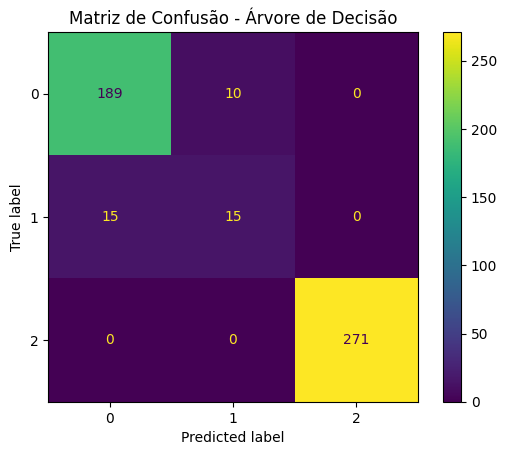

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Calcular acurácia
acuracia = accuracy_score(y_test_encoded, y_pred)
print(f"Acurácia do modelo: {acuracia:.4f} ({acuracia*100:.2f}%)")

# Matriz de confusão
cm = confusion_matrix(y_test_encoded, y_pred)
print(f"\nMatriz de Confusão:\n{cm}")

# Relatório de classificação
print(f"\nRelatório de Classificação:\n{classification_report(y_test_encoded, y_pred)}")

# Visualizar matriz de confusão
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree.classes_)
disp.plot()
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()